# Wildfire Time-to-Threat Modeling

This notebook explores wildfire behavior and builds models to predict whether a fire will reach an evacuation zone within multiple time horizons: 12, 24, 48, and 72 hours.

The workflow follows a practical machine-learning structure:

> **Note:** This notebook expects `train.csv` and `test.csv` to be available in the same directory.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
from itertools import product
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
#let's compare the shape of train and test dataset

print(f'Train data shape:{train.shape}')
print(f'Test data shape: {test.shape}')

print(f'Columns in train set but missing in test data: {set(train.columns) -set(test.columns)}') #ie columns to be predicted

Train data shape:(221, 37)
Test data shape: (95, 35)
Columns in train set but missing in test data: {'event', 'time_to_hit_hours'}


## 1. Data Overview

Let's inspect the schema, data types, missing values and duplicate rows before modeling. This helps catch obvious data-quality issues early.


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

In [6]:
#most values are floats while a few are of type int
#let's see what stands out in columns of type int
int_cols = train.select_dtypes(include='int').columns
print(f'Columns in train data that are of type Int: {train[int_cols].nunique().sort_values()}')

test_int_columns= test.select_dtypes(include='int').columns
#print(f'Columns in test data that are of type Int: {test[test_int_columns].nunique().sort_values()}')

#event day of week, month, hour should be categorical variables

Columns in train data that are of type Int: low_temporal_resolution_0_5h      2
event                             2
event_start_dayofweek             7
event_start_month                 9
num_perimeters_0_5h              12
event_start_hour                 22
event_id                        221
dtype: int64


In [ ]:
# Basic data-quality checks for missing values and duplicate rows.

print(f'Columns with missing values in train data: {train.isna().sum()[train.isna().sum()>0].index.tolist()}')
print(f'Columns with missing values in test data: {test.isna().sum()[test.isna().sum()>0].index.tolist()}')

#no missing values

#check for duplicate entries
print(f'Duplicated entries in train data: {train.duplicated().mean()}')
print(f'Duplicated entries in test data: {test.duplicated().mean()}')

#no duplicated entries

Columns with missing values in train data: []
Columns with missing values in test data: []
Duplicated entries in train data: 0.0
Duplicated entries in test data: 0.0


In [8]:
# Confirm that the event target is binary: 1 = fire reached an evacuation zone, 0 = censored/no hit observed.

print(f'Unique values of event column: {train['event'].unique()}')

Unique values of event column: [0 1]


## 2. Summary Statistics and Redundant Features

The next cells inspect numeric distributions and check whether some engineered columns are mathematical transformations of other columns. This matters because redundant features can make interpretation harder, even if tree models can often handle them.


In [ ]:
train.describe().T
#some values like dist_change_ci_0_5h,projected_advance_m have a big difference btn mean, median and max values 
# but let's keep in mind that fires are rare extreme events, so could have an interesting relationship with our variables
# so let's decide on outliers after doing some more analyis/EDA


,count,mean,std,min,25%,50%,75%,max
event_id,221.0,5.384397e+07,2.507456e+07,1.089246e+07,3.209326e+07,5.244094e+07,7.457274e+07,9.933973e+07
num_perimeters_0_5h,221.0,2.063348e+00,2.578859e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.700000e+01
dt_first_last_0_5h,221.0,9.798688e-01,1.738052e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.356107e+00,4.994457e+00
low_temporal_resolution_0_5h,221.0,7.285068e-01,4.457395e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
area_first_ha,221.0,6.191316e+02,1.447724e+03,3.752484e-02,2.521906e+01,1.101493e+02,4.850926e+02,1.194239e+04
area_growth_abs_0_5h,221.0,2.633240e+01,1.874370e+02,-2.156175e-05,0.000000e+00,0.000000e+00,0.000000e+00,2.508041e+03
area_growth_rel_0_5h,221.0,1.789087e-01,1.302001e+00,-1.437844e-07,0.000000e+00,0.000000e+00,0.000000e+00,1.788970e+01
area_growth_rate_ha_per_h,221.0,6.167128e+00,4.046737e+01,-5.292846e-06,0.000000e+00,0.000000e+00,0.000000e+00,5.204430e+02
log1p_area_first,221.0,4.683276e+00,2.083529e+00,3.683791e-02,3.266487e+00,4.710874e+00,6.186399e+00,9.387933e+00
log1p_growth,221.0,3.893465e-01,1.340348e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.827656e+00


In [ ]:
#let's check if the following columns are also similar
print(f'log1p_area_first & area_first_ha columns are equal elementwise:{np.allclose(train['log1p_area_first'], np.log1p(train['area_first_ha']))}')
print(f'corr btn log1p_area_first & area_first_ha: {train['log1p_area_first'].corr(train['area_first_ha'])}')

print(f'log1p_growth & area_growth_abs_0_5h columns are equal elementwise:{np.allclose(train['log1p_growth'], np.log1p(train['area_growth_abs_0_5h']))}')
print(f'corr btn log1p_growth & area_growth_abs_0_5h: {train['log1p_growth'].corr(train['area_growth_abs_0_5h'])}')

print(f'log_area_ratio_0_5h & area_growth_rate_ha_per_h columns are equal elementwise:{np.allclose(train['log_area_ratio_0_5h'], np.log1p(train['area_growth_rate_ha_per_h']))}')
print(f'corr btn log_area_ratio_0_5h & area_growth_rate_ha_per_h: {train['log_area_ratio_0_5h'].corr(train['area_growth_rate_ha_per_h'])}')

# we will drop area_first_ha as it's mathematically similar to log1p_growth
# there are other columns that are similar based on definition
# for example, relative_growth_0_5h & area_growth_rel_0_5h & area_growth_abs_0_5h,
# radial_growth_m & radial_growth_rate_m_per_h, dt_first_last_0_5h & low_temporal_resolution_0_5h; alignment_cos & alignment_abs, along_track_speed & closing_speed_m_per_h, centroid_displacement_m & centroid_speed_m_per_h, spread_bearing_deg & spread_bearing_sin/cos and dist_change_ci_0_5h, dist_slope_ci_0_5h, dist_std_ci_0_5h, projected_advance_m,closing_speed_abs_m_per_h are all similar to closing_speed_m_per_h

train = train.drop(columns=['area_first_ha','relative_growth_0_5h','area_growth_abs_0_5h','area_growth_rel_0_5h','radial_growth_m','dt_first_last_0_5h', 'alignment_abs','along_track_speed','centroid_displacement_m','spread_bearing_deg','dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'projected_advance_m','closing_speed_abs_m_per_h','dist_std_ci_0_5h'])
test = test.drop(columns=['area_first_ha','relative_growth_0_5h','area_growth_abs_0_5h','area_growth_rel_0_5h','radial_growth_m','dt_first_last_0_5h', 'alignment_abs','along_track_speed','centroid_displacement_m','spread_bearing_deg','dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'projected_advance_m','closing_speed_abs_m_per_h','dist_std_ci_0_5h'])

log1p_area_first & area_first_ha columns are equal elementwise:True
corr btn log1p_area_first & area_first_ha: 0.6219120982577327
log1p_growth & area_growth_abs_0_5h columns are equal elementwise:False
corr btn log1p_growth & area_growth_abs_0_5h: 0.6691600153307519
log_area_ratio_0_5h & area_growth_rate_ha_per_h columns are equal elementwise:False
corr btn log_area_ratio_0_5h & area_growth_rate_ha_per_h: 0.5793686896251323


## 3. Exploratory Data Analysis

This section studies how the target behaves over time and how key fire-movement variables differ between fires that hit evacuation zones and those that do not.


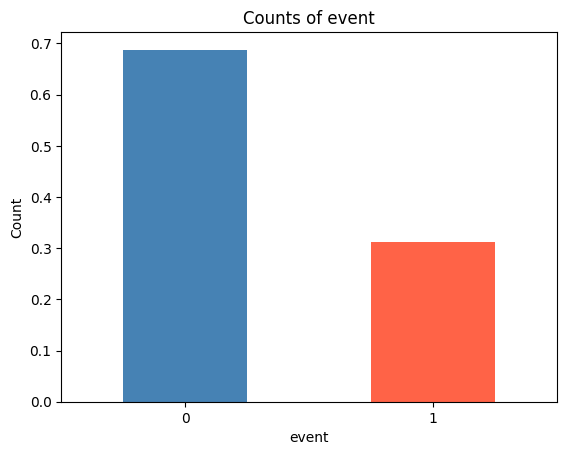

In [11]:
#let's inspect the target distribution
train['event'].value_counts(normalize=True).sort_index().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xlabel('event')
plt.ylabel('Count')
plt.title("Counts of event")
plt.xticks(rotation=0)
plt.show()

#There's a moderate imbalance in this dataset- ~69% censored (event=0), ~31% hit (event=1)
#About 70% of the fires didn't reach an evacuation zone within 72 hours which reflects real world dynamics

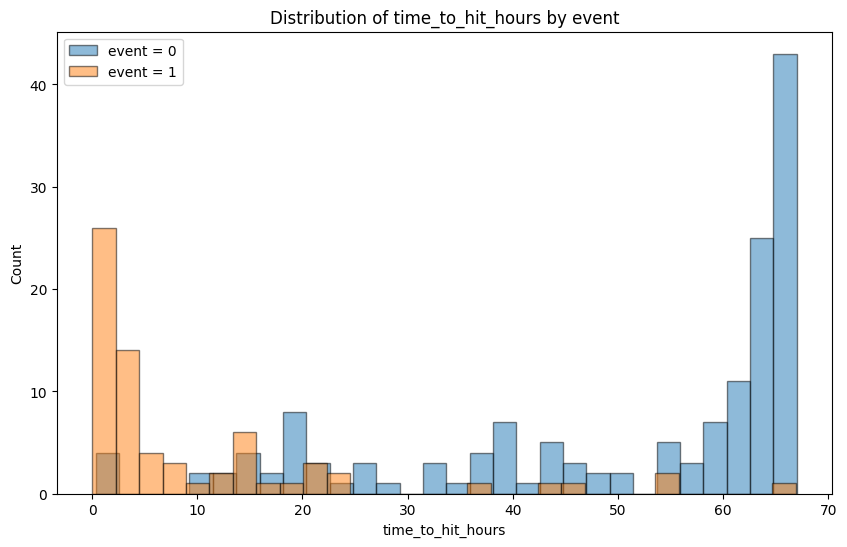

In [12]:
# let's compare time-to-hit distributions for censored vs observed hit events.

plt.figure(figsize=(10, 6))
train.loc[train['event'] == 0, 'time_to_hit_hours'].plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    label='event = 0',
    edgecolor='black'
)

train.loc[train['event'] == 1, 'time_to_hit_hours'].plot(
    kind='hist',
    bins=30,
    alpha=0.5,
    label='event = 1',
    edgecolor='black'
)
plt.xlabel('time_to_hit_hours')
plt.ylabel('Count')
plt.title('Distribution of time_to_hit_hours by event')
plt.legend()
plt.show()

#seems like most fires that reach an evacuation zone do so within the first 10 hours

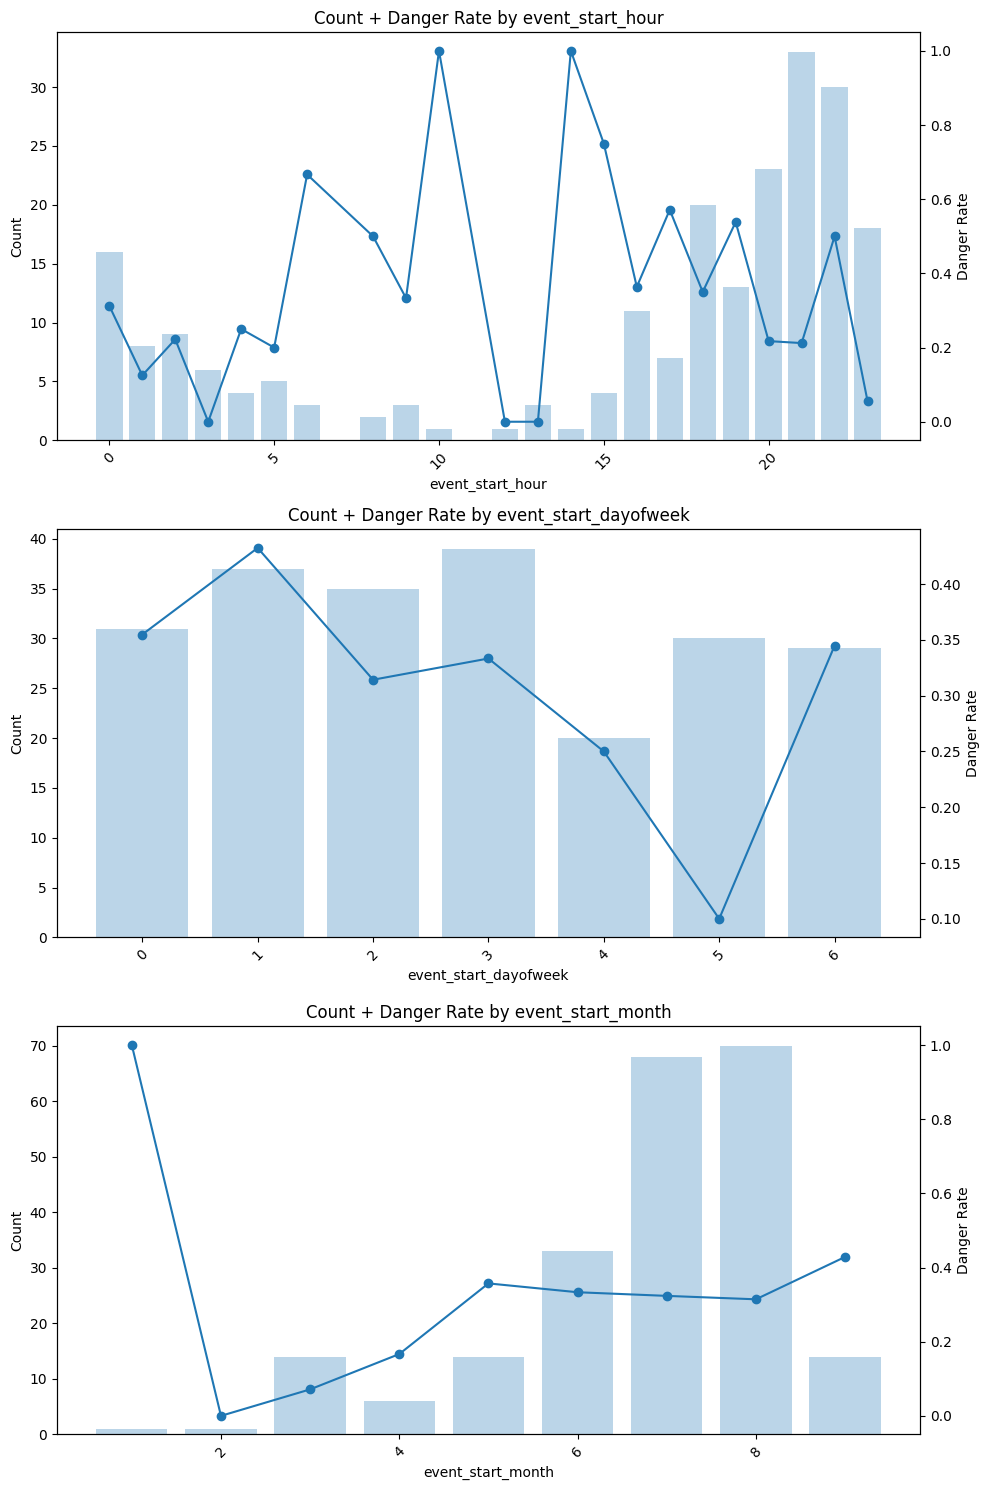

In [ ]:
##let's see the times when fires reach evacuation zones- we'll use 'danger rate' as a measure of % of fires that reach evacuation zones
event_cols = [col for col in train.columns if col.startswith('event_start_')]

fig, axes = plt.subplots(len(event_cols), 1, figsize=(10, 5 * len(event_cols)))

if len(event_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, event_cols):

    stats = train.groupby(col)['event'].agg(['count', 'sum'])
    stats['danger_rate'] = stats['sum'] / stats['count']

    # Bar plot for count
    ax.bar(stats.index, stats['count'], alpha=0.3)
    ax.set_ylabel('Count')

    # Line plot for danger rate (second axis)
    ax2 = ax.twinx()
    ax2.plot(stats.index, stats['danger_rate'], marker='o')
    ax2.set_ylabel('Danger Rate')

    ax.set_title(f'Count + Danger Rate by {col}')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#fires are more common in the evening after 6pm
#danger rate is relatively consistent across hours- at about 30%- let's use time bucketing for feature engineering
#occurrence of fires is relatively balanced across days of week but fires that happen on day 1 are more likely to reach evacuation zones while fires that happen on day 5 are least likely- but due to the small sample sizes, mean day-level patterns may not generalize so we'll just drop this column
#fires are most likely to occur in June, July, August but those that happen in September are more likely to reach evacuation zone(~40%) despite low count- we can create a peak fire season column based on this observation

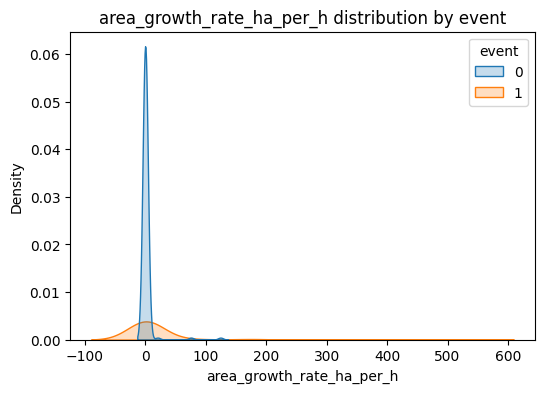

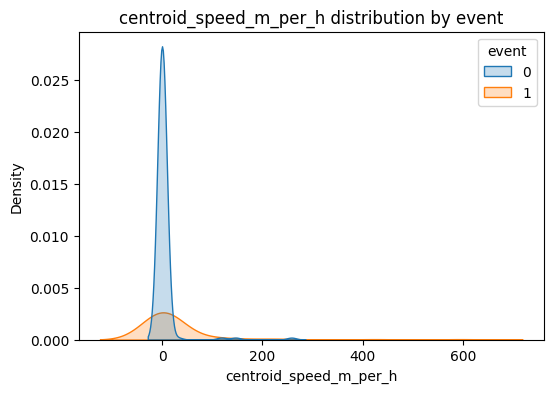

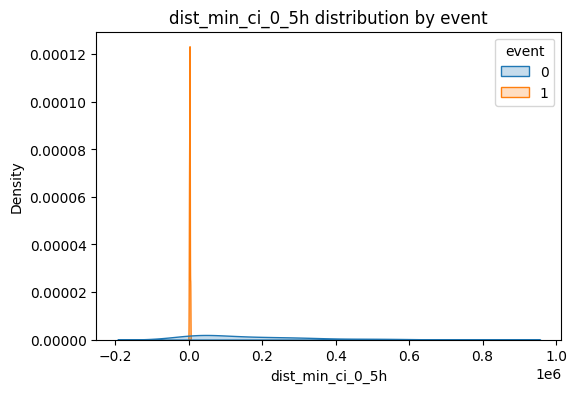

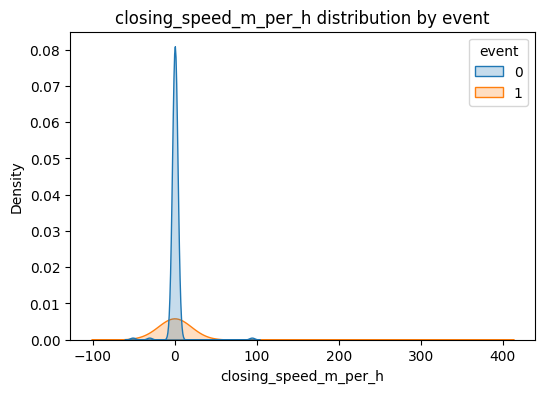

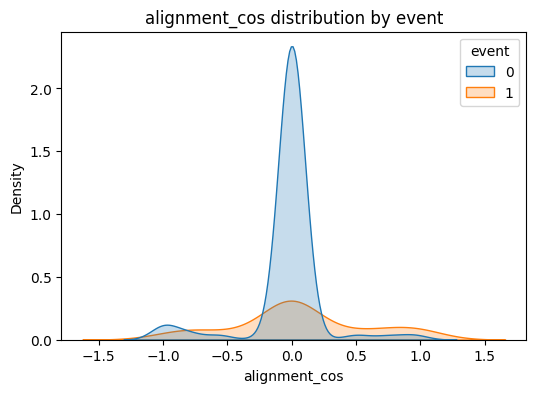

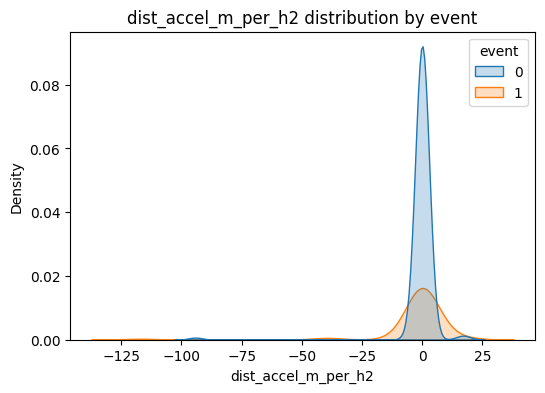

       area_growth_rate_ha_per_h  centroid_speed_m_per_h  dist_min_ci_0_5h  \
event                                                                        
0                       1.476825                3.662570      179832.30310   
1                      16.499391               30.217648        2285.81835   

       closing_speed_m_per_h  alignment_cos  dist_accel_m_per_h2  
event                                                             
0                   0.081931      -0.034955            -0.426819  
1                   6.293863       0.061081            -2.159919  


In [ ]:
#let's see fire movements and relationship with reaching evac zone
fire_mvmt_features = ['area_growth_rate_ha_per_h','centroid_speed_m_per_h','dist_min_ci_0_5h','closing_speed_m_per_h',
'alignment_cos','dist_accel_m_per_h2']

for col in fire_mvmt_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=train, x=col, hue='event', fill=True)
    plt.title(f'{col} distribution by event')
    plt.show()

#most of the variables seem to be highly skewed with long tails and concentration near 0 which makes it difficult to interpret visually

#let's try using stats to see the difference btn the 2 groups
print(train.groupby('event')[fire_mvmt_features].mean())
#area_growth_rate_ha_per_h -> dangerous fires grow faster
#centroid_speed_m_per_h ->dangerous fires move faster
#dist_min_ci_0_5h ->dangerous fires start closer to evac zones
#closing_speed_m_per_h ->dangerous fires have a higher closing speed towards evac zones
#alignment_cos -> dangerous fires are more directionally aligned toward evac zones
#dist_accel_m_per_h2 -> dangerous fires decelerate significantly as they approach evac zone-maybe coz they approach very quickly and they're already very close


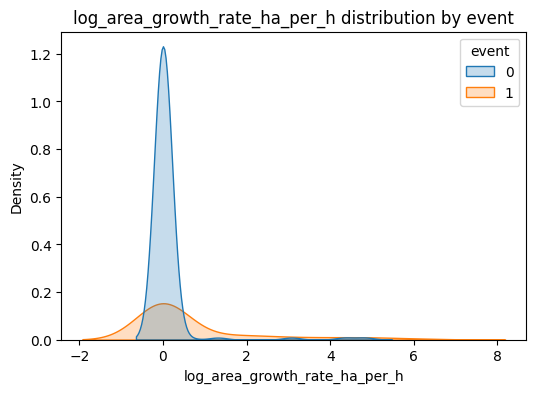

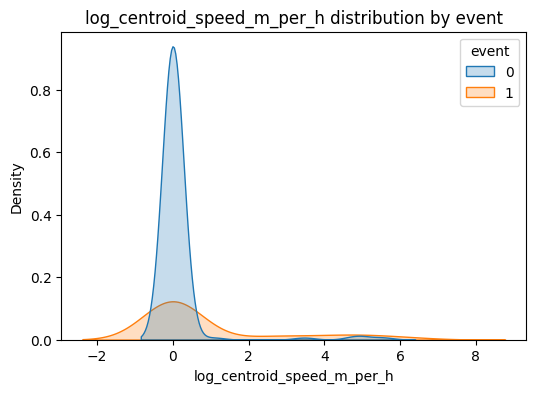

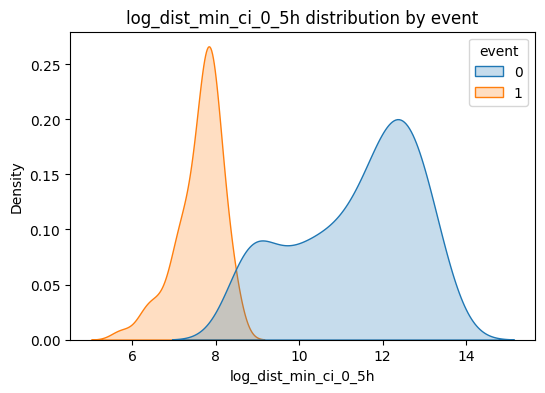

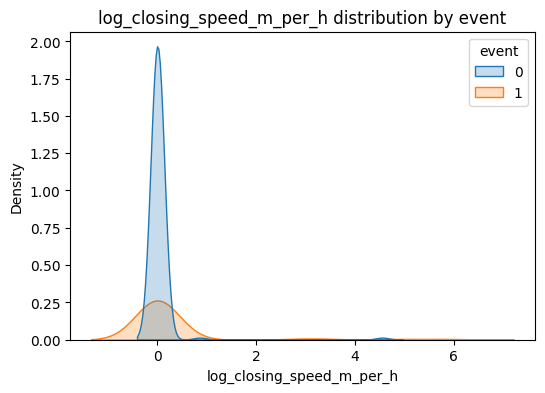

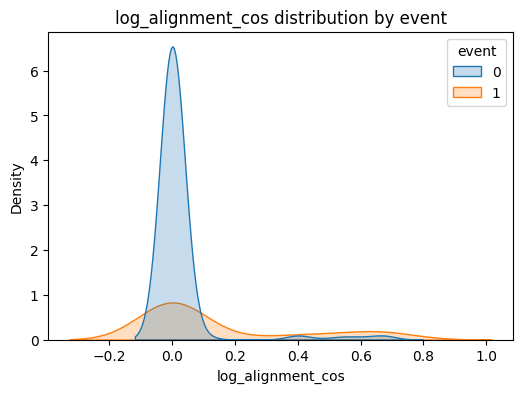

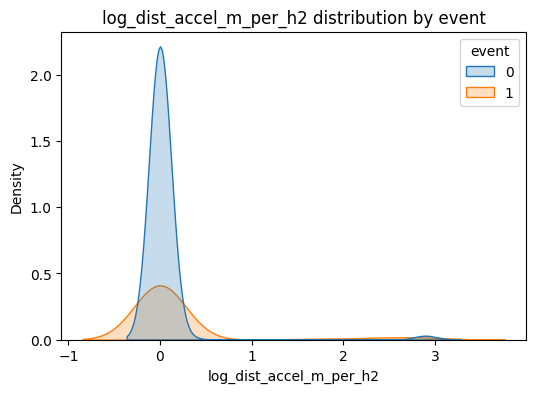

In [15]:
#let's also try using log transformation to see if there's a clear separation btn the events
train_df = train.copy()
for col in fire_mvmt_features:
    train_df[f'log_{col}'] = np.log1p(train[col].clip(lower=0))

for col in fire_mvmt_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=train_df, x=f'log_{col}', hue='event', fill=True)
    plt.title(f'log_{col} distribution by event')
    plt.show()

#interestingly,most values are still concentrated close to 0 so this could be a general behavior and not a scaling effect
#however, from the tails, we can say that dangerous fires have a higher area_growth_rate_ha_per_h, centroid_speed_m_per_h,closing_speed_m_per_h,alignment_cos but a lower dist_min_ci_0_5h
#we won't use these log transformed columns as we'll be using tree based models due to the relationships observed not being linear

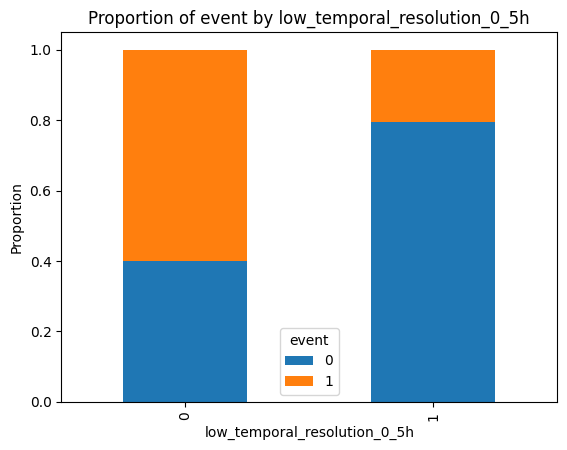

In [20]:
#let's explore the low_temporal_resolution_0_5h column
# low_temporal_resolution_0_5h- if time btn each parameter < 0.5h or only 1 perimeter is observed, then 1, else 0
temporal_res = pd.crosstab(
    train['low_temporal_resolution_0_5h'],
    train['event'],
    normalize='index'
)

temporal_res.plot(kind='bar', stacked=True)
plt.title('Proportion of event by low_temporal_resolution_0_5h')
plt.ylabel('Proportion')
plt.show()

#if low temporal resolution= 1 means there's low temporal resolution while if low temporal resolution=0 then we have high temporal resolution
#seems like when the fires reach evacuation zones when there's high temporal resolution, ie low temporal resolution = 0
#well observed fires are more dangerous- we'll keep this column as it captures both the fire danger level and its features

In [17]:
#let's check if this relationship is statistically associated with the event target
from scipy.stats import chi2_contingency

temporal_res_table = pd.crosstab(train['low_temporal_resolution_0_5h'], train['event'])
chi2, p, dof, expected = chi2_contingency(temporal_res_table)

print('chi2:', chi2)
print('p-value:', p)
print('degrees of freedom:', dof)
print('expected counts:\n', expected)

#low_temporal_resolution_0_5h shows a statistically significant association with event (chi-square = 29.95 with 1 df shows a large effect size btn event and low_temporal_resolution_0_5h, p < 0.001).

chi2: 29.9513294228206
p-value: 4.4302803498939903e-08
degrees of freedom: 1
expected counts:
 [[ 41.26696833  18.73303167]
 [110.73303167  50.26696833]]


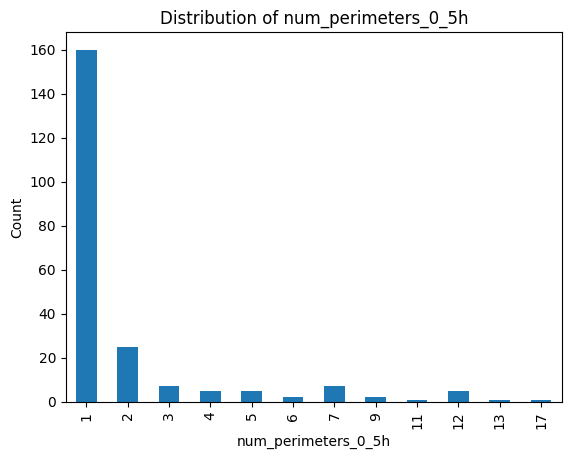

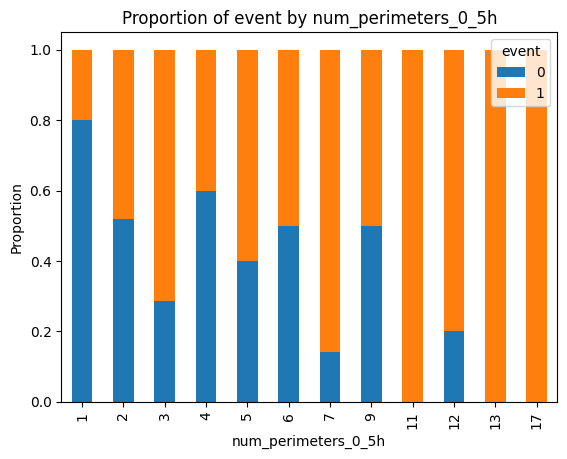

In [18]:
#how about num_perimeters_0_5h?
train['num_perimeters_0_5h'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('num_perimeters_0_5h')
plt.ylabel('Count')
plt.title('Distribution of num_perimeters_0_5h')
plt.show()

ct = pd.crosstab(
    train['num_perimeters_0_5h'],
    train['event'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True)
plt.title('Proportion of event by num_perimeters_0_5h')
plt.ylabel('Proportion')
plt.show()

#from first graph, we see that most of the fires have few perimeters but dangerous fires generally have a higher number of perimeters
## of perimeters tells us how many updates were recorded while temporal resolution tells us if the data is reliable so we'll keep both

### Survival View of Fire Risk

Kaplan-Meier curves are useful here because this is a time-to-event problem. They show the probability that a fire has **not yet** reached an evacuation zone over time.


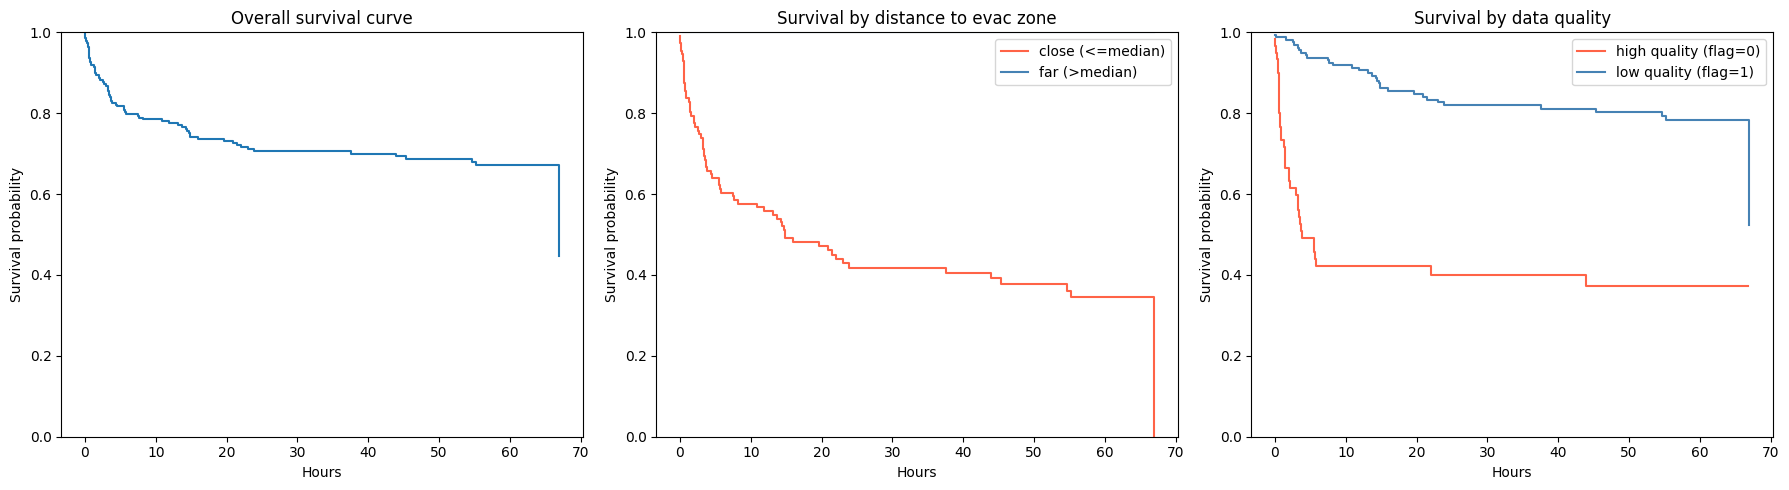

In [19]:
# let's plot kaplan-meier curves to see how the fires behave over time
# kaplan-meier curves show survival probability over time
# y-axis: proportion of fires that have NOT yet hit an evacuation zone
# drops occur when fires hit the zone, censored fires are handled honestly

from sksurv.nonparametric import kaplan_meier_estimator

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#1. overall survival curve
time, survival = kaplan_meier_estimator(
    train['event'].astype(bool),
    train['time_to_hit_hours']
)
axes[0].step(time, survival, where='post')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Survival probability')
axes[0].set_title('Overall survival curve')
axes[0].set_ylim(0, 1)

#2. by distance to zone (above/below median)
dist_median = train['dist_min_ci_0_5h'].median()
for label, mask, color in [
    ('close (<=median)', train['dist_min_ci_0_5h'] <= dist_median, 'tomato'),
    ('far (>median)', train['dist_min_ci_0_5h'] > dist_median, 'steelblue')
]:
    time, survival = kaplan_meier_estimator(
        train.loc[mask, 'event'].astype(bool),
        train.loc[mask, 'time_to_hit_hours']
    )
    axes[1].step(time, survival, where='post', label=label, color=color)
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Survival probability')
axes[1].set_title('Survival by distance to evac zone')
axes[1].set_ylim(0, 1)
axes[1].legend()

#3. by data quality (low_temporal_resolution)
for label, mask, color in [
    ('high quality (flag=0)', train['low_temporal_resolution_0_5h'] == 0, 'tomato'),
    ('low quality (flag=1)', train['low_temporal_resolution_0_5h'] == 1, 'steelblue')
]:
    time, survival = kaplan_meier_estimator(
        train.loc[mask, 'event'].astype(bool),
        train.loc[mask, 'time_to_hit_hours']
    )
    axes[2].step(time, survival, where='post', label=label, color=color)
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Survival probability')
axes[2].set_title('Survival by data quality')
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()

#overall curve: survival drops steeply in first 10-15 hours confirming earlier finding that most dangerous fires hit early
#curve flattens after ~20h - fires that survive past this point are unlikely to hit the evac zone at all

#by distance: fires starting closer to the zone have steeper early drop confirms dist_min_ci_0_5h as a strong predictor

#by data quality: well-observed fires (flag=0) drop faster, consistent with chi-square finding

## 4. Correlation Check

Highly correlated variables can carry similar information. Here, we identify strongly correlated feature pairs and remove less interpretable/redundant columns before modeling.


In [21]:
#let's check correlation btn columns to remove those that are redundant
num_cols = train.select_dtypes(include='number').columns.tolist()
corr_matrix = train[num_cols].corr().abs()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
upper = corr_matrix.where(mask)

high_corr_pairs = [
    (row, col, upper.loc[row, col])
    for row in upper.index
    for col in upper.columns
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.80
]

high_corr_df = pd.DataFrame(high_corr_pairs, columns=['col1', 'col2', 'corr'])
print(high_corr_df.sort_values('corr', ascending=False))

cols_to_check = list(set(high_corr_df['col1']).union(set(high_corr_df['col2'])))

#will also drop log_area_ratio_0_5h and radial_growth_rate_m_per_h due to high corr with area_growth_rate_ha_per_h and them being less interpretable; log1p_growth and dist_accel_m_per_h2 due to high corr with centroid_speed_m_per_h and closing_speed_m_per_h

                         col1                        col2      corr
7  radial_growth_rate_m_per_h      centroid_speed_m_per_h  0.989008
5         log_area_ratio_0_5h  radial_growth_rate_m_per_h  0.926074
6         log_area_ratio_0_5h      centroid_speed_m_per_h  0.923686
8       closing_speed_m_per_h         dist_accel_m_per_h2  0.899086
3                log1p_growth  radial_growth_rate_m_per_h  0.838867
0   area_growth_rate_ha_per_h  radial_growth_rate_m_per_h  0.825357
1   area_growth_rate_ha_per_h       closing_speed_m_per_h  0.815404
4                log1p_growth      centroid_speed_m_per_h  0.812041
2                log1p_growth         log_area_ratio_0_5h  0.810486


In [22]:
#due to high correlation >.8 and reasons above
to_drop=['log_area_ratio_0_5h','radial_growth_rate_m_per_h','dist_accel_m_per_h2','log1p_growth']

train = train.drop(columns=to_drop)
test = test.drop(columns=to_drop)

## 5. Feature Engineering

The goal of this section is to convert raw wildfire measurements into signals that are easier for models to use, such as seasonality, time-of-day buckets, distance-to-zone, and directional threat features.


In [23]:
# we'll convert event start hour into time-of-day buckets.
# This gives tree models simple categorical splits without treating hour as strictly linear.

def time_of_day(hour):
    if 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    elif 18 <= hour < 24:
        return 'evening'
    else:
        return 'night'

train['time_of_day'] = train['event_start_hour'].apply(time_of_day)
test['time_of_day'] = test['event_start_hour'].apply(time_of_day)

# then one-hot encode to give model clean binary splits on each bucket
train = pd.get_dummies(train, columns=['time_of_day'])
test = pd.get_dummies(test, columns=['time_of_day'])

# Flag peak fire-season months
train['is_peak_fire_season'] = train['event_start_month'].isin([6,7,8,9]).astype(int)
test['is_peak_fire_season'] = test['event_start_month'].isin([6,7,8,9]).astype(int)

# Drop raw columns after encoding the useful seasonal/time signals
train = train.drop(columns=['event_start_hour', 'event_start_dayofweek', 'event_start_month'])
test = test.drop(columns=['event_start_hour', 'event_start_dayofweek', 'event_start_month'])

In [24]:
train.columns

Index(['event_id', 'num_perimeters_0_5h', 'low_temporal_resolution_0_5h',
       'area_growth_rate_ha_per_h', 'log1p_area_first',
       'centroid_speed_m_per_h', 'spread_bearing_sin', 'spread_bearing_cos',
       'dist_min_ci_0_5h', 'closing_speed_m_per_h', 'dist_fit_r2_0_5h',
       'alignment_cos', 'cross_track_component', 'time_to_hit_hours', 'event',
       'time_of_day_afternoon', 'time_of_day_evening', 'time_of_day_morning',
       'time_of_day_night', 'is_peak_fire_season'],
      dtype='object')

In [25]:
#next, we'll do some feature engineering based on EDA results
# These features combine distance, direction, size, and speed into threat-oriented signals.

#estimated time for fire to reach the evac zone at its current closing speed
train['closing_in_time'] = train['dist_min_ci_0_5h']/ (train['closing_speed_m_per_h'] + 1)
test['closing_in_time'] = test['dist_min_ci_0_5h']/ (test['closing_speed_m_per_h'] + 1)

# a fire moving directly toward the evac zone and with a fast closing speed is more dangerous than either signal alone
train['fire_danger'] = train['alignment_cos'] * train['closing_speed_m_per_h']
test['fire_danger'] = test['alignment_cos'] * test['closing_speed_m_per_h']

# a large fire close to an evac zone is more dangerous than a small fire at same distance
train['size_distance_ratio'] = train['log1p_area_first'] / (train['dist_min_ci_0_5h'] + 1)
test['size_distance_ratio'] = test['log1p_area_first'] / (test['dist_min_ci_0_5h'] + 1)

# directional threat: how aligned is the fire and how fast is it closing in
train['directed_threat'] = train['alignment_cos'] * train['closing_in_time']
test['directed_threat'] = test['alignment_cos'] * test['closing_in_time']


## 6. Horizon Labels and Baseline Classifier

The competition asks for probabilities across multiple future time windows. A simple baseline is to train one binary classifier per horizon.


In [26]:
#let's check class balance across the time horizons
horizons = [12, 24, 48, 72]

for h in horizons:
    dist= ((train['time_to_hit_hours'] <= h) & (train['event'] == 1)).astype(int)
    print(h, dist.mean())

#no significant class imbalance, also seems most dangerous fires happen within 12 hours so this time horizon will be hardest to predict, 
# then 6% more btn 12-24hrs, etc

12 0.22171945701357465
24 0.2850678733031674
48 0.2986425339366516
72 0.31221719457013575


In [27]:
# Baseline modeling set up
# We remove target columns before training and hold out a validation set.

from sklearn.model_selection import train_test_split

#drop target cols to avoid leakage
target_cols = ['event', 'time_to_hit_hours','event_id']

X = train.drop(columns=target_cols)
y_event = train['event']
y_time_to_hit = train['time_to_hit_hours']


X_train, X_val, y_event_train, y_event_val, y_time_to_hit_train, y_time_to_hit_val = train_test_split(
    X, y_event, y_time_to_hit, test_size=0.2, random_state=42, stratify=y_event)

#using stratification keeps the overall hit/non-hit proportion similar in train and validation.

In [28]:
#goal is to see probability of fire hitting an evacuation zone within 12,24,48,72 hours
# Train one Random Forest classifier per prediction horizon
# Each model estimates: P(fire hits evacuation zone by h hours)

from sklearn.ensemble import RandomForestClassifier
y_train_ = {}
y_val_ = {}

#since RF cant directly train on event+time, we need to create a binary label for each time horizon
for h in horizons:
    y_train_[h] = ((y_time_to_hit_train <= h) & (y_event_train == 1)).astype(int)
    y_val_[h] = ((y_time_to_hit_val <= h) & (y_event_val == 1)).astype(int)

#train one model for each time horizon as different time horizons have different feature dynamics
models = {}

for h in horizons:
    model = RandomForestClassifier(
        n_estimators=100, #build 100 decision trees, RF combines them and averages their predictions
        max_depth=5, #limits how deep each tree should grow
        min_samples_leaf=5, #prevents the tree from creating tiny, overly specific rules
        class_weight='balanced', #give more weight to the minority class
        random_state=42
    )
    model.fit(X_train, y_train_[h])
    models[h] = model

In [29]:
#we predict the probabilities and ensure monotonicity is enforced(prob_12h <= prob_24h <= prob_48h <= prob_72h)
preds = {}
for h in horizons:
    preds[h] = models[h].predict_proba(X_val)[:, 1]

preds_df = pd.DataFrame(preds, index=X_val.index)
preds_df.columns = [f'prob_{h}h' for h in horizons]

# enforce monotonicity as each model is trained independently with different labels so they have no knowledge of each other
preds_df['prob_24h'] = np.maximum(preds_df['prob_24h'], preds_df['prob_12h'])
preds_df['prob_48h'] = np.maximum(preds_df['prob_48h'], preds_df['prob_24h'])
preds_df['prob_72h'] = np.maximum(preds_df['prob_72h'], preds_df['prob_48h'])

In [30]:
# next, we'll evaluate each of the time horizons
# AUC (Area Under ROC Curve): measures how well model ranks dangerous fires above safe ones- 0.5 = random, 1.0 = perfect
# log_loss: measures divergence between predicted probabilities and actual outcomes. Lower is better - 0 is perfect
# Brier Score: measures mean squared error between predicted probability and actual outcome. Lower is better - 0 is perfect

from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

for h in horizons:
    y_actual = y_val_[h]
    y_pred = preds_df[f'prob_{h}h']

    auc = roc_auc_score(y_actual, y_pred)
    ll = log_loss(y_val_[h], preds[h])
    brier = brier_score_loss(y_actual, y_pred)

    print(f'{h}h')
    print(f'AUC: {auc:.4f}')
    print(f'Log Loss: {ll:.4f}')
    print(f'Brier Score:{brier:.4f}')

#this performance is impressive->high AUC, very low log loss and even lower brier scores, though 48h and 72h auc is concerning. Prediction gets better with time, ie, 12h has lowest AUC so is the hardest to predict as model has limited signal to distinguish them from fires that won't hit at all

12h
AUC: 0.9628
Log Loss: 0.2627
Brier Score:0.0848
24h
AUC: 0.9520
Log Loss: 0.2119
Brier Score:0.0499
48h
AUC: 1.0000
Log Loss: 0.0720
Brier Score:0.0093
72h
AUC: 1.0000
Log Loss: 0.0533
Brier Score:0.0062


In [31]:
#let's check most important features at 12h time horizon

feature_imp_12h = pd.Series(models[12].feature_importances_,index=X_train.columns).sort_values(ascending=False)

print(feature_imp_12h.head(5))

#so distance of fire in the first 5 hours, closing_in_time, size_distance_ratio matter the most

dist_min_ci_0_5h                0.321073
closing_in_time                 0.248506
size_distance_ratio             0.188564
low_temporal_resolution_0_5h    0.051707
num_perimeters_0_5h             0.045190
dtype: float64


## 7. Survival Modeling

Because the target includes both event occurrence and time-to-event, survival models are a natural fit. They can use censored observations more directly than separate binary classifiers.


In [32]:
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import brier_score_loss
from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv

# Create the survival target.
# event=True means the fire reached the evacuation zone; time is the observed/censored time.
y_surv = Surv.from_arrays(
    event=train['event'].astype(bool),
    time=train['time_to_hit_hours']
)

# Stratification key capturing both event status and timing.
# This helps each fold contain a reasonable mix of censored, early-hit, mid-hit, and late-hit examples.
def make_strat_key(row):
    if row['event'] == 0:
        return 'censored'
    elif row['time_to_hit_hours'] <= 12:
        return 'hit_early'
    elif row['time_to_hit_hours'] <= 48:
        return 'hit_mid'
    else:
        return 'hit_late'

strat_key = train.apply(make_strat_key, axis=1)

# The dataset has a small least-populated stratification class.
# Using 3 folds avoids the warning caused by trying to split a class with only ~3 rows into 5 folds.
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

horizons = np.array([12, 24, 48, 72])


def calculate_weighted_brier(y_val, surv_funcs, horizons=horizons):
    briers_by_horizon = {}

    for h in horizons:
        probs = [1 - fn(min(h, fn.domain[1])) for fn in surv_funcs]
        y_actual = ((y_val['event']) & (y_val['time'] <= h)).astype(int)
        briers_by_horizon[h] = brier_score_loss(y_actual, probs)

    weighted_brier = (
        0.3 * briers_by_horizon[24] +
        0.4 * briers_by_horizon[48] +
        0.3 * briers_by_horizon[72]
    )

    return weighted_brier, briers_by_horizon


def calculate_hybrid_score(c_index, weighted_brier):
    """Competition metric: 0.3 * C-index + 0.7 * (1 - weighted Brier)."""
    return 0.3 * c_index + 0.7 * (1 - weighted_brier)


fold_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_key)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_surv[train_idx], y_surv[val_idx]

    rsf = RandomSurvivalForest(
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features=0.7,
        random_state=42,
        n_jobs=-1
    )
    rsf.fit(X_tr, y_tr)

    surv_funcs = rsf.predict_survival_function(X_val)
    weighted_brier, _ = calculate_weighted_brier(y_val, surv_funcs)
    c_idx = concordance_index_censored(y_val['event'], y_val['time'], rsf.predict(X_val))[0]
    fold_hybrid = calculate_hybrid_score(c_idx, weighted_brier)

    fold_scores.append({
        'fold': fold + 1,
        'weighted_brier': weighted_brier,
        'c_index': c_idx,
        'hybrid_score': fold_hybrid
    })

    print(
        f"Fold {fold+1} | Weighted Brier: {weighted_brier:.4f} | "
        f"C-index: {c_idx:.4f} | Hybrid: {fold_hybrid:.4f}"
    )

scores_df = pd.DataFrame(fold_scores)
print(f"\nMean Weighted Brier: {scores_df['weighted_brier'].mean():.4f} ± {scores_df['weighted_brier'].std():.4f}")
print(f"Mean C-index: {scores_df['c_index'].mean():.4f} ± {scores_df['c_index'].std():.4f}")
print(f"Mean Hybrid Score: {scores_df['hybrid_score'].mean():.4f} ± {scores_df['hybrid_score'].std():.4f}")

Fold 1 | Weighted Brier: 0.0169 | C-index: 0.9369 | Hybrid: 0.9693
Fold 2 | Weighted Brier: 0.0067 | C-index: 0.9505 | Hybrid: 0.9804
Fold 3 | Weighted Brier: 0.0154 | C-index: 0.9346 | Hybrid: 0.9696

Mean Weighted Brier: 0.0130 ± 0.0055
Mean C-index: 0.9406 ± 0.0086
Mean Hybrid Score: 0.9731 ± 0.0064


### Random Survival Forest Hyperparameter Search

This section manually searches a small Random Survival Forest hyperparameter grid. Because the competition metric combines ranking quality and probability accuracy, the selected model is chosen by **hybrid score**, not by weighted Brier score alone.

In [33]:
from itertools import product

param_grid = {
    'n_estimators': [100, 150, 200],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10, 15],
    'max_features': [0.3, 0.5, 0.7]
}

best_hybrid_rsf = -np.inf
best_score = np.inf  # kept as the best Brier score for reporting/comparison
best_params = None
results = []

total = (
    len(param_grid['n_estimators']) *
    len(param_grid['min_samples_split']) *
    len(param_grid['min_samples_leaf']) *
    len(param_grid['max_features'])
)
print(f"Total combinations to try: {total}")

for n_est, min_split, min_leaf, max_feat in product(
    param_grid['n_estimators'],
    param_grid['min_samples_split'],
    param_grid['min_samples_leaf'],
    param_grid['max_features']
):
    fold_briers = []
    fold_cidx = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_key)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_surv[train_idx], y_surv[val_idx]

        rsf = RandomSurvivalForest(
            n_estimators=n_est,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            max_features=max_feat,
            random_state=42,
            n_jobs=-1
        )
        rsf.fit(X_tr, y_tr)

        surv_funcs = rsf.predict_survival_function(X_val)
        weighted_brier, _ = calculate_weighted_brier(y_val, surv_funcs)
        c_idx = concordance_index_censored(
            y_val['event'], y_val['time'], rsf.predict(X_val)
        )[0]

        fold_briers.append(weighted_brier)
        fold_cidx.append(c_idx)

    mean_brier = np.mean(fold_briers)
    std_brier = np.std(fold_briers)
    mean_cidx = np.mean(fold_cidx)
    rsf_hybrid_score = calculate_hybrid_score(mean_cidx, mean_brier)

    results.append({
        'n_estimators': n_est,
        'min_samples_split': min_split,
        'min_samples_leaf': min_leaf,
        'max_features': max_feat,
        'mean_brier': mean_brier,
        'std_brier': std_brier,
        'mean_cidx': mean_cidx,
        'hybrid_score': rsf_hybrid_score
    })

    # Select by the competition's full hybrid metric, not Brier alone.
    if rsf_hybrid_score > best_hybrid_rsf:
        best_hybrid_rsf = rsf_hybrid_score
        best_score = mean_brier
        best_params = {
            'n_estimators': n_est,
            'min_samples_split': min_split,
            'min_samples_leaf': min_leaf,
            'max_features': max_feat
        }

results_df = pd.DataFrame(results).sort_values('hybrid_score', ascending=False)
best_rsf_row = results_df.iloc[0]
rsf_hybrid = best_rsf_row['hybrid_score']

print(results_df.head(10).to_string(index=False))
print(f"\nBest RSF params by hybrid score: {best_params}")
print(f"Best RSF mean Brier: {best_score:.4f}")
print(f"Best RSF mean C-index: {best_rsf_row['mean_cidx']:.4f}")
print(f"Best RSF hybrid score: {rsf_hybrid:.5f}")

Total combinations to try: 81
 n_estimators  min_samples_split  min_samples_leaf  max_features  mean_brier  std_brier  mean_cidx  hybrid_score
          100                 20                10           0.7    0.013753   0.003919   0.944644      0.973766
          100                 10                10           0.7    0.013753   0.003919   0.944644      0.973766
          150                 10                10           0.7    0.014164   0.004062   0.945370      0.973696
          150                 20                10           0.7    0.014164   0.004062   0.945370      0.973696
          100                 10                 5           0.7    0.012425   0.004186   0.940620      0.973488
          200                 10                10           0.7    0.014311   0.004226   0.944618      0.973368
          200                 20                10           0.7    0.014311   0.004226   0.944618      0.973368
          150                 10                 5           0.7  

### Gradient Boosting Survival Model

Gradient Boosting Survival Analysis is tested as an alternative to Random Survival Forest. It can work well on smaller datasets because trees are built sequentially, with each tree correcting earlier errors.


In [34]:
# Compare RSF against a baseline Gradient Boosting Survival model.
# GBS can work well on smaller tabular datasets because trees are built sequentially,
# with each tree correcting errors from the previous ensemble.
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

fold_scores_gbs = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_key)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_surv[train_idx], y_surv[val_idx]

    gbs = GradientBoostingSurvivalAnalysis(
        loss='coxph',
        n_estimators=200,
        learning_rate=0.1,
        max_depth=2,
        min_samples_leaf=15,
        max_features=0.5,
        random_state=42
    )
    gbs.fit(X_tr, y_tr)

    surv_funcs = gbs.predict_survival_function(X_val)
    weighted_brier, _ = calculate_weighted_brier(y_val, surv_funcs)
    c_idx = concordance_index_censored(y_val['event'], y_val['time'], gbs.predict(X_val))[0]
    fold_hybrid = calculate_hybrid_score(c_idx, weighted_brier)

    fold_scores_gbs.append({
        'fold': fold + 1,
        'weighted_brier': weighted_brier,
        'c_index': c_idx,
        'hybrid_score': fold_hybrid
    })

    print(
        f"Fold {fold+1} | Weighted Brier: {weighted_brier:.4f} | "
        f"C-index: {c_idx:.4f} | Hybrid: {fold_hybrid:.4f}"
    )

scores_gbs_df = pd.DataFrame(fold_scores_gbs)

print(f"\nGBS Mean Weighted Brier: {scores_gbs_df['weighted_brier'].mean():.4f} ± {scores_gbs_df['weighted_brier'].std():.4f}")
print(f"GBS Mean C-index: {scores_gbs_df['c_index'].mean():.4f} ± {scores_gbs_df['c_index'].std():.4f}")
print(f"GBS Mean Hybrid Score: {scores_gbs_df['hybrid_score'].mean():.4f} ± {scores_gbs_df['hybrid_score'].std():.4f}")

# Compare against the baseline RSF from the previous cell.
rsf_baseline_hybrid = scores_df['hybrid_score'].mean()
gbs_baseline_hybrid = scores_gbs_df['hybrid_score'].mean()

print(f"\nRSF Baseline Hybrid Score: {rsf_baseline_hybrid:.4f}")
print(f"GBS Baseline Hybrid Score: {gbs_baseline_hybrid:.4f}")
print(f"Baseline winner by hybrid score: {'GBS' if gbs_baseline_hybrid > rsf_baseline_hybrid else 'RSF'}")

Fold 1 | Weighted Brier: 0.0155 | C-index: 0.9398 | Hybrid: 0.9711
Fold 2 | Weighted Brier: 0.0074 | C-index: 0.9561 | Hybrid: 0.9816
Fold 3 | Weighted Brier: 0.0129 | C-index: 0.9438 | Hybrid: 0.9741

GBS Mean Weighted Brier: 0.0119 ± 0.0041
GBS Mean C-index: 0.9466 ± 0.0085
GBS Mean Hybrid Score: 0.9756 ± 0.0054

RSF Baseline Hybrid Score: 0.9731
GBS Baseline Hybrid Score: 0.9756
Baseline winner by hybrid score: GBS


### Gradient Boosting Hyperparameter Search

This grid search tunes the GBS model and uses the same competition-style hybrid score for model selection. This keeps model selection aligned with the final evaluation metric.

In [35]:
param_grid_gbs = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_leaf': [5, 10, 15],
    'max_features': [0.3, 0.5, 0.7]
}

best_hybrid_gbs = -np.inf
best_score_gbs = np.inf  # kept as the best Brier score for reporting/comparison
best_params_gbs = None
results_gbs = []

total_gbs = (
    len(param_grid_gbs['n_estimators']) *
    len(param_grid_gbs['learning_rate']) *
    len(param_grid_gbs['max_depth']) *
    len(param_grid_gbs['min_samples_leaf']) *
    len(param_grid_gbs['max_features'])
)

print(f"Total combinations to try: {total_gbs}")

for n_est, lr, max_d, min_leaf, max_f in product(
    param_grid_gbs['n_estimators'],
    param_grid_gbs['learning_rate'],
    param_grid_gbs['max_depth'],
    param_grid_gbs['min_samples_leaf'],
    param_grid_gbs['max_features']
):
    fold_briers = []
    fold_cidx = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_key)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y_surv[train_idx], y_surv[val_idx]

        gbs = GradientBoostingSurvivalAnalysis(
            loss='coxph',
            n_estimators=n_est,
            learning_rate=lr,
            max_depth=max_d,
            min_samples_leaf=min_leaf,
            max_features=max_f,
            random_state=42
        )
        gbs.fit(X_tr, y_tr)

        surv_funcs = gbs.predict_survival_function(X_val)
        weighted_brier, _ = calculate_weighted_brier(y_val, surv_funcs)
        c_idx = concordance_index_censored(
            y_val['event'], y_val['time'], gbs.predict(X_val)
        )[0]

        fold_briers.append(weighted_brier)
        fold_cidx.append(c_idx)

    mean_brier = np.mean(fold_briers)
    std_brier = np.std(fold_briers)
    mean_cidx = np.mean(fold_cidx)
    gbs_hybrid_score = calculate_hybrid_score(mean_cidx, mean_brier)

    results_gbs.append({
        'n_estimators': n_est,
        'learning_rate': lr,
        'max_depth': max_d,
        'min_samples_leaf': min_leaf,
        'max_features': max_f,
        'mean_brier': mean_brier,
        'std_brier': std_brier,
        'mean_cidx': mean_cidx,
        'hybrid_score': gbs_hybrid_score
    })

    # Select by the competition's full hybrid metric, not Brier alone.
    if gbs_hybrid_score > best_hybrid_gbs:
        best_hybrid_gbs = gbs_hybrid_score
        best_score_gbs = mean_brier
        best_params_gbs = {
            'n_estimators': n_est,
            'learning_rate': lr,
            'max_depth': max_d,
            'min_samples_leaf': min_leaf,
            'max_features': max_f
        }

results_gbs_df = pd.DataFrame(results_gbs).sort_values('hybrid_score', ascending=False)
best_gbs_row = results_gbs_df.iloc[0]
gbs_hybrid = best_gbs_row['hybrid_score']

print(results_gbs_df.head(10).to_string(index=False))
print(f"\nBest GBS params by hybrid score: {best_params_gbs}")
print(f"Best GBS mean Brier: {best_score_gbs:.4f}")
print(f"Best GBS mean C-index: {best_gbs_row['mean_cidx']:.4f}")
print(f"Best GBS hybrid score: {gbs_hybrid:.5f}")

# Compare best tuned models using the same metric used for selection.
print(f"\nBest tuned RSF hybrid score: {rsf_hybrid:.5f}")
print(f"Best tuned GBS hybrid score: {gbs_hybrid:.5f}")
print(f"Best tuned model by hybrid score: {'GBS' if gbs_hybrid > rsf_hybrid else 'RSF'}")

selected_model_name = 'GBS' if gbs_hybrid > rsf_hybrid else 'RSF'
print(f"Selected primary model: {selected_model_name}")

Total combinations to try: 243
 n_estimators  learning_rate  max_depth  min_samples_leaf  max_features  mean_brier  std_brier  mean_cidx  hybrid_score
          200            0.1          4                15           0.7    0.010631   0.003732   0.949171      0.977310
          200            0.1          2                15           0.7    0.010722   0.003020   0.948791      0.977132
          200            0.1          3                15           0.7    0.010633   0.003451   0.948398      0.977076
          200            0.1          3                 5           0.7    0.011554   0.004954   0.950351      0.977018
          200            0.1          3                10           0.7    0.011151   0.003733   0.949109      0.976927
          150            0.1          2                15           0.7    0.011583   0.003401   0.948787      0.976528
          150            0.1          3                15           0.7    0.011392   0.003834   0.948027      0.976433
         

## 8. Submission Generation

After comparing models, the selected models are retrained on all training data and used to generate test-set probabilities for each prediction horizon.

Model selection is based on the competition's hybrid metric: 0.3 * C-index + 0.7 * (1 - weighted Brier)

This avoids choosing a model based only on Brier score when the final evaluation also rewards ranking quality through C-index.

A simple 50/50 RSF + GBS ensemble is also generated as a secondary submission candidate. The ensemble is useful to test because the two model families may make slightly different errors, but it should not be described as better unless it improves cross-validation or leaderboard performance.

In [36]:
# Retrain the tuned RSF on all training data and generate test probabilities.
rsf_final = RandomSurvivalForest(
    **best_params,
    random_state=42,
    n_jobs=-1
)
rsf_final.fit(X, y_surv)

X_test = test[X.columns]
surv_funcs_test = rsf_final.predict_survival_function(X_test)

submission_rsf = pd.DataFrame()
submission_rsf['event_id'] = test['event_id']

# Convert survival curves into event probabilities by horizon.
for h in horizons:
    probs = [1 - fn(min(h, fn.domain[1])) for fn in surv_funcs_test]
    submission_rsf[f'prob_{h}h'] = probs

# Enforce monotonicity: probability of hit by 72h should be >= probability by 48h, etc.
submission_rsf['prob_24h'] = np.maximum(submission_rsf['prob_24h'], submission_rsf['prob_12h'])
submission_rsf['prob_48h'] = np.maximum(submission_rsf['prob_48h'], submission_rsf['prob_24h'])
submission_rsf['prob_72h'] = np.maximum(submission_rsf['prob_72h'], submission_rsf['prob_48h'])

for h in horizons:
    submission_rsf[f'prob_{h}h'] = submission_rsf[f'prob_{h}h'].round(4)

submission_rsf.to_csv('submission_rsf.csv', index=False)

print("RSF submission sample:")
print(submission_rsf.head())
print("\nRSF probability summary:")
print(submission_rsf.describe())

RSF submission sample:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602    0.0017    0.0017    0.0017    0.0017
1  13353600    0.5949    0.9234    0.9749    0.9933
2  13942327    0.0000    0.0000    0.0000    0.0000
3  16112781    0.5948    0.9191    0.9731    0.9988
4  17132808    0.0337    0.0417    0.0422    0.0422

RSF probability summary:
           event_id   prob_12h   prob_24h  prob_48h   prob_72h
count  9.500000e+01  95.000000  95.000000  95.00000  95.000000
mean   5.695393e+07   0.186266   0.267276   0.28344   0.299720
std    2.329721e+07   0.289484   0.398717   0.42266   0.446892
min    1.066260e+07   0.000000   0.000000   0.00000   0.000000
25%    4.027536e+07   0.000000   0.000000   0.00000   0.000000
50%    5.480111e+07   0.001700   0.002500   0.00250   0.002500
75%    7.536942e+07   0.453900   0.809800   0.88565   0.986300
max    9.964946e+07   0.978300   0.985000   0.99100   1.000000


In [37]:
# Retrain the tuned GBS on all training data and generate test probabilities.
gbs_final = GradientBoostingSurvivalAnalysis(
    loss='coxph',
    **best_params_gbs,
    random_state=42
)
gbs_final.fit(X, y_surv)

surv_funcs_test_gbs = gbs_final.predict_survival_function(X_test)

submission_gbs = pd.DataFrame()
submission_gbs['event_id'] = test['event_id']

for h in horizons:
    probs = [1 - fn(min(h, fn.domain[1])) for fn in surv_funcs_test_gbs]
    submission_gbs[f'prob_{h}h'] = probs

# Enforce monotonicity.
submission_gbs['prob_24h'] = np.maximum(submission_gbs['prob_24h'], submission_gbs['prob_12h'])
submission_gbs['prob_48h'] = np.maximum(submission_gbs['prob_48h'], submission_gbs['prob_24h'])
submission_gbs['prob_72h'] = np.maximum(submission_gbs['prob_72h'], submission_gbs['prob_48h'])

for h in horizons:
    submission_gbs[f'prob_{h}h'] = submission_gbs[f'prob_{h}h'].round(4)

submission_gbs.to_csv('submission_gbs.csv', index=False)

print("GBS submission sample:")
print(submission_gbs.head())
print("\nGBS probability summary:")
print(submission_gbs.describe())

GBS submission sample:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602    0.0078    0.0238    0.0337    0.0898
1  13353600    0.6270    0.9525    0.9871    1.0000
2  13942327    0.0069    0.0210    0.0299    0.0798
3  16112781    0.8639    0.9979    0.9998    1.0000
4  17132808    0.0116    0.0354    0.0502    0.1316

GBS probability summary:
           event_id   prob_12h   prob_24h   prob_48h   prob_72h
count  9.500000e+01  95.000000  95.000000  95.000000  95.000000
mean   5.695393e+07   0.205681   0.286565   0.306320   0.355704
std    2.329721e+07   0.335401   0.412757   0.426421   0.419647
min    1.066260e+07   0.004500   0.013800   0.019700   0.053000
25%    4.027536e+07   0.006100   0.018700   0.026500   0.071100
50%    5.480111e+07   0.007000   0.021500   0.030500   0.081600
75%    7.536942e+07   0.407000   0.801050   0.900050   0.998200
max    9.964946e+07   1.000000   1.000000   1.000000   1.000000


In [38]:
# Secondary submission candidate: simple 50/50 average of tuned RSF and tuned GBS predictions.
# This should be treated as an experimental submission unless it improves validation or leaderboard performance.
submission_ensemble = pd.DataFrame()
submission_ensemble['event_id'] = test['event_id']

for h in horizons:
    submission_ensemble[f'prob_{h}h'] = (
        (submission_rsf[f'prob_{h}h'] + submission_gbs[f'prob_{h}h']) / 2
    )

# Enforce monotonicity after averaging.
submission_ensemble['prob_24h'] = np.maximum(submission_ensemble['prob_24h'], submission_ensemble['prob_12h'])
submission_ensemble['prob_48h'] = np.maximum(submission_ensemble['prob_48h'], submission_ensemble['prob_24h'])
submission_ensemble['prob_72h'] = np.maximum(submission_ensemble['prob_72h'], submission_ensemble['prob_48h'])

for h in horizons:
    submission_ensemble[f'prob_{h}h'] = submission_ensemble[f'prob_{h}h'].round(4)

submission_ensemble.to_csv('submission_ensemble.csv', index=False)

print("\nRSF sample:")
print(submission_rsf.head(3))
print("\nGBS sample:")
print(submission_gbs.head(3))
print("\nEnsemble sample:")
print(submission_ensemble.head(3))


RSF sample:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602    0.0017    0.0017    0.0017    0.0017
1  13353600    0.5949    0.9234    0.9749    0.9933
2  13942327    0.0000    0.0000    0.0000    0.0000

GBS sample:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602    0.0078    0.0238    0.0337    0.0898
1  13353600    0.6270    0.9525    0.9871    1.0000
2  13942327    0.0069    0.0210    0.0299    0.0798

Ensemble sample:
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602    0.0048    0.0128    0.0177    0.0458
1  13353600    0.6110    0.9380    0.9810    0.9966
2  13942327    0.0034    0.0105    0.0150    0.0399


## 9. Feature Importance and Model Simplification

Feature importance is used as a sanity check and to test whether a smaller feature set can preserve similar performance.


In [39]:
# Inspect feature importance from the final Gradient Boosting Survival model.
# This helps identify low-signal features for potential simplification.

gbs_feat_imp= pd.Series(gbs_final.feature_importances_, index=X.columns).sort_values(ascending=False)
print(gbs_feat_imp)

dist_min_ci_0_5h                0.532418
closing_in_time                 0.231270
size_distance_ratio             0.121496
num_perimeters_0_5h             0.037861
log1p_area_first                0.026305
low_temporal_resolution_0_5h    0.015288
directed_threat                 0.009929
alignment_cos                   0.009248
time_of_day_evening             0.008646
spread_bearing_cos              0.005288
centroid_speed_m_per_h          0.001000
cross_track_component           0.000771
spread_bearing_sin              0.000234
time_of_day_afternoon           0.000176
is_peak_fire_season             0.000069
closing_speed_m_per_h           0.000000
dist_fit_r2_0_5h                0.000000
time_of_day_morning             0.000000
time_of_day_night               0.000000
fire_danger                     0.000000
area_growth_rate_ha_per_h       0.000000
dtype: float64


In [40]:
# Optional feature reduction step.
# These features showed low importance in the final GBS model, so we drop them and can retrain to check whether performance holds.

to_drop_zero = [
    'closing_speed_m_per_h',
    'dist_fit_r2_0_5h',
    'spread_bearing_sin',
    'fire_danger'
]

train = train.drop(columns=to_drop_zero)
test = test.drop(columns=to_drop_zero)

## 10. Next Steps

The reduced feature set is ready for retraining. A clean final GitHub version could include a short comparison table showing baseline RF, RSF, GBS, and reduced-feature GBS results.


In [41]:
# Rebuild the feature matrix after feature reduction.
# Next step: rerun the modeling cells above with this reduced feature set and compare validation performance.

target_cols = ['event', 'time_to_hit_hours','event_id']

X = train.drop(columns=target_cols)
